In [1]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import ICIW_Plots

plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [2]:
run_ids = [
    "9zdn8e4q",  #  30 ml/min, 1 bar, RT
    "9e45c3ra",  # 120 ml/min, 4 bar, RT
    "hdjk7ueu",  #  30 ml/min, 1 bar, heated
    "xoqfjwvh",  # 120 ml/min, 4 bar, heated
]

labels = [
    r"$p=1\;\mathrm{bar},\quad T=298\;\mathrm{K}$",
    r"$p=4\;\mathrm{bar},\quad T=298\;\mathrm{K}$",
    r"$p=1\;\mathrm{bar},\quad T=523\;\mathrm{K}$",
    r"$p=4\;\mathrm{bar},\quad T=523\;\mathrm{K}$",
]

In [3]:
names = []
paths = []
for run_id in run_ids:
    name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
    names.append(name)
    paths.append(ckpt_path)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [4]:
Es = []
ts = []
delta_ts = []
for name, path in zip(names, paths):
    print(name, path)
    model = RTDModule.load_from_checkpoint(path)
    Es.append(model.net.E[0].detach().numpy())
    ts.append(model.net.conv_layers[0].t_kernel.detach().numpy())
    delta_ts.append(model.net.delta_t[0].item())

noble-capybara-175 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-9zdn8e4q-v0\model.ckpt
volcanic-armadillo-174 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-9e45c3ra-v0\model.ckpt
sparkling-disco-229 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-hdjk7ueu-v0\model.ckpt
breezy-sun-230 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-xoqfjwvh-v0\model.ckpt


In [5]:
from scipy.integrate import simpson

taus = []
for E, t, delta_t in zip(Es, ts, delta_ts):
    I = simpson(E, x=t) + 1 / 2 * E[0] * delta_t + 1 / 2 * E[-1] * delta_t
    dummy_I = I - E[0] * delta_t
    print(f"{I=: .3f}")
    tau = simpson(t * E / dummy_I, x=t)
    taus.append(tau)
    sigma = simpson((t - tau) ** 2 * E / dummy_I, x=t)
    print(f"{tau=:.2f}")
    print(f"{sigma=:.2f}")

I= 1.001
tau=24.11
sigma=76.78
I= 1.005
tau=25.21
sigma=79.97
I= 1.003
tau=21.41
sigma=76.49
I= 1.001
tau=21.26
sigma=66.03


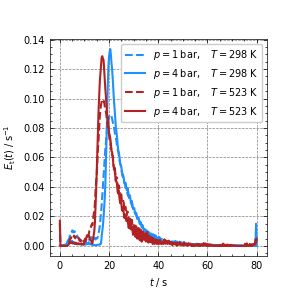

In [6]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E_\mathrm{t}(t)\;/\;\mathrm{s}^{-1}$",
)

for label, E, t, tau in zip(labels, Es, ts, taus):
    color = "firebrick" if ("523" in label) else "dodgerblue"
    linestyle = "--" if ("p=1" in label) else "-"
    ax.plot(t, E, label=label, c=color, linestyle=linestyle)
    # ax.axvline(tau, color=color)

ax.legend()
# plt.savefig("RTD_total_compTp.png", dpi=600)
# plt.savefig("RTD_total_compTp.pdf")
# plt.savefig("RTD_total_compTp.svg")
plt.show()

In [8]:
import torch

In [9]:
t_in = torch.linspace(0, 300, 1201)
x_in = torch.zeros_like(t_in)
x_in[8:250] = 0.5
x_in[250:1180] = torch.sin(t_in[0 : 1180 - 250] / 10) * 0.2 + 0.5

print(x_in.reshape(1, 1, -1).shape)
print(t_in.reshape(1, -1).shape)

torch.Size([1, 1, 1201])
torch.Size([1, 1201])


In [10]:
res = model(x_in.reshape(1, 1, -1), t_in.reshape(1, -1))

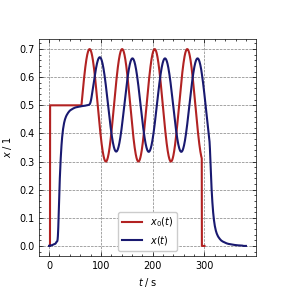

In [11]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    # left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$x \;/\; 1$",
)
ax.plot(
    t_in,
    x_in,
    color="firebrick",
    label="$x_0(t)$",
)
ax.plot(
    res[1].detach().numpy().squeeze(),
    res[0].detach().numpy().squeeze(),
    label="$x(t)$",
    color="midnightblue",
)
ax.legend()

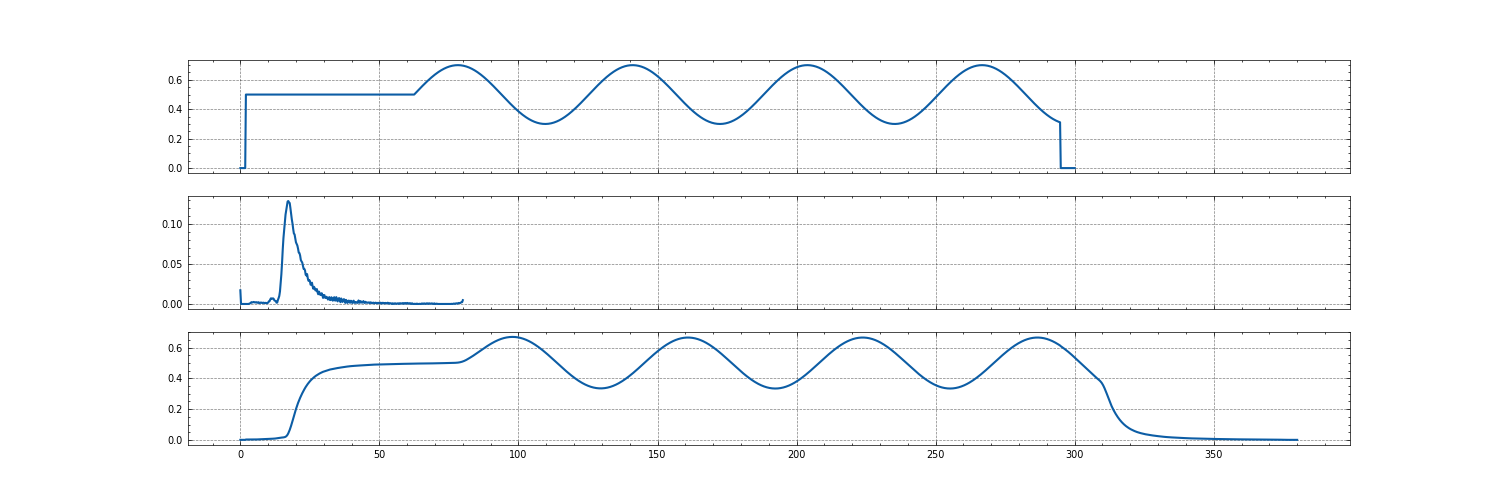

In [16]:
fix, axs = plt.subplots(3, 1, sharex=True, figsize=(15, 5))

axs[0].plot(t_in, x_in)
axs[1].plot(
    t,
    model.net.E[0].detach().numpy(),
)
axs[2].plot(
    res[1].detach().numpy().squeeze(),
    res[0].detach().numpy().squeeze(),
)
plt.savefig("slider.svg")